17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Accuracy: 0.6555

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.68      0.67      1047
           1       0.64      0.63      0.64       953

    accuracy                           0.66      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.66      0.66      0.66      2000



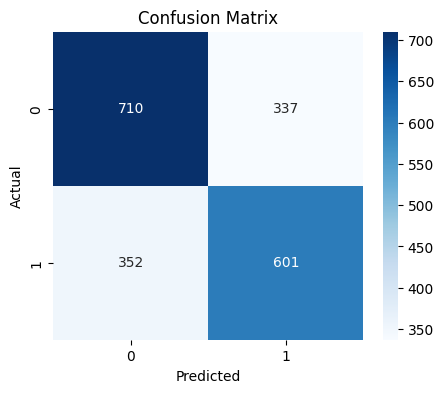


Best K: {'n_neighbors': 7}
Best Cross-validation Score: 0.6957998556351156


In [3]:
# ================================
# PRACTICAL 4 – KNN on IMDB Dataset
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------
# STEP 1: Load Dataset
# ----------------------------

from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

# Load IMDB dataset (Top 10,000 words)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ----------------------------
# Convert integer sequences back to text
# ----------------------------

word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(text):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])

X_train_text = [decode_review(review) for review in X_train[:5000]]
X_test_text = [decode_review(review) for review in X_test[:2000]]

y_train_small = y_train[:5000]
y_test_small = y_test[:2000]

# ----------------------------
# STEP 2: TF-IDF Vectorization
# ----------------------------

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# ----------------------------
# STEP 3: Apply KNN
# ----------------------------

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train_small)

y_pred = knn.predict(X_test_tfidf)

# ----------------------------
# STEP 4: Evaluation
# ----------------------------

accuracy = accuracy_score(y_test_small, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_small, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_small, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------
# STEP 5: Hyperparameter Tuning
# ----------------------------

param_grid = {
    'n_neighbors': [3,5,7]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3)
grid.fit(X_train_tfidf, y_train_small)

print("\nBest K:", grid.best_params_)
print("Best Cross-validation Score:", grid.best_score_)